In [31]:
from IPython.display import Image

#  (지역) 특성 

## 4. Scale 불변 

- Harris corner detector의 문제점

   - 검출방법만 제공, 특징점에대한 설명/기술을 제공하지 못함
   - Scale(물체와 사진기의 거리)가 바꾸면 검출이 안됨
 
- Pyramidal 영상  
  - 영상을 down-sampling 하여 여러 스캐일의 영상을 만듦 (이때 aliasing이 없도록 low pass filter를 사전에 적용)
  

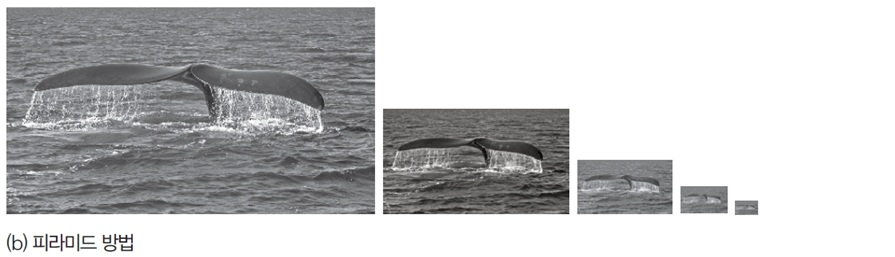

In [4]:
Image("pyramidalimages.jpg", width=720)

### 스케일 공간 scale space 이론

- 사람은 스케일 불변인 특징 사용: 거리에 상관없이 같은 물체를 같다고 인식
- 사진기와 대상 물제의 거리가 달라졌을때 어떤 차이가 생기는지에 대한 연구 (Lindberg 등)
-  Gaussian Blur에 의한 방법

     - Lindberg등이 이때 이미지 크기를 줄이는 대신, Gaussian Blur의 sigma 값과 검출 필터의 크기를 키우는 방법을 사용해도 됨을 밝혀냄.
  
   $$ L(x,y,σ)=G(x,y,σ)∗I(x,y) $$

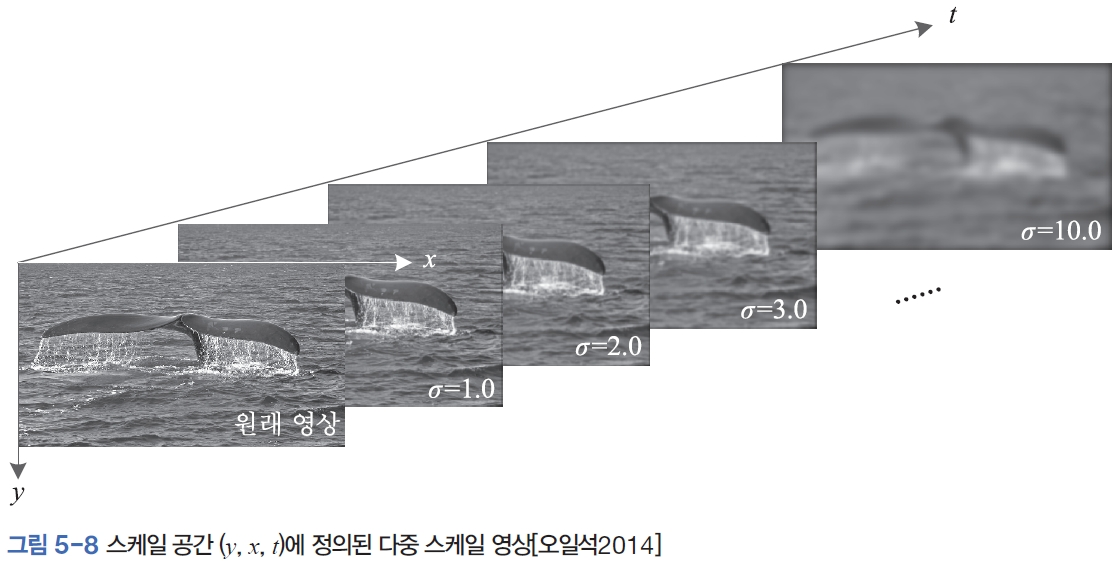

In [3]:
Image("그림 5-8.jpg", width=640)

### scale invariant 특징점 추출 방법

-  입력 이미지 I(y,x)를 어러 scale의 이미지로 변환 ($ \sigma $), 피라미드 이미지셋이라고 함.
-  이 피라미드 셋을 미분하여 미분 피라미드 영상셋을 만듬. $ I(\sigma) = G(\sigma) I_{xx} (y,x) $
-  이 영상의 x, y, $\sigma$ 3개의 축에서 극점을 찾아 이를 특징점으로 사용.
   
     - Laplacian  
         $$ \nabla I_{\sigma} (y,x) = {I(\sigma})_{x,x} (y,x) + I(\sigma)_{y,y} (y,x) $$
     - Normalized Laplacian
          - 이미지에 Gaussian blur를 하게되면 점점더 Laplacian 강도가 약해지므로 이를 보상하기 위하여 이를 곱해줌.
       $$ \nabla_{norm} I (y,x) = \sigma^2 (I(\sigma)_{x,x} + I(\sigma)_{y,y}) $$
 
 



##  5. SIFT 

- SIFT (2002년 발표) 는 딥러닝을 제외한 컴퓨터 비젼연구 중에서 가장 인용이 많이된 중요한 결과로 응용 범위가 넓고 현재도 사용되고 있음 

- SIFT 검출 => 특징점에서 기술자를 추출 = > 특징점을 매칭


### 1) SIFT 특징점 검 출

#### 1단계: 다중 스케일 영상 구축
 
- 가우시안 스무딩과 피라미드 방법을 결합해 사용 
- Octave set
    - 원 이미지에서 가로, 세로 1/2씩  down sampling한 동일한 해상도의 영상들 
        - 총 ocatve의 수는 이미지 크기에 따라 다름: $ log_2 (min(W,H))−3), 즉 32 화소수준까지 down sampling 함$
    - 한 octave 셋에 Gaussian 필터를 적용하여 총 6단계의 (실제적인) scale을 구성
        - 6개의 이미지 -> 5개의 DOG 생성 -> 3개의 scale에 (i)서의 특징점 검출 

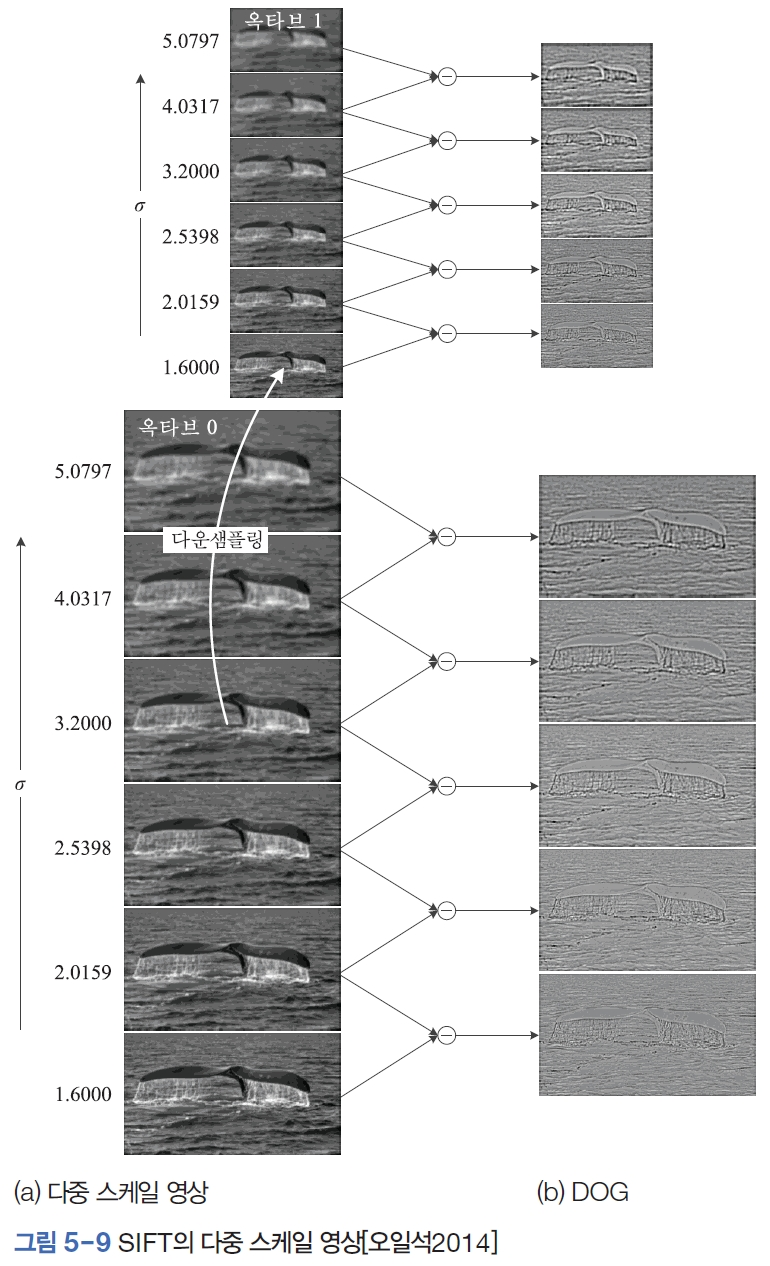

In [7]:
Image("그림 5-9.jpg", width=640)

#### 2단계: 다중 스케일 영상에 미분 적용

- DOG (difference of Gaussian) 사용
  - 정규 라플라시안을 사용해야하는 계상량이 적고, 결과가 거의 유사한 DOG을 발명
  - DOG는 가우시안 영상은 이미 있고 이웃한 가우시안을 빼면 되기 때문에 획기적으로 빠름


#### 3단계:  극점 검출 

 - 수평, 수직, scale (o, i) 3축에서 극대 극소를 추출
     - 9 + 8 + 9 총 26개와 비교함.
 - NMS을 수행하여 인접하지 않은 하나만 선택 



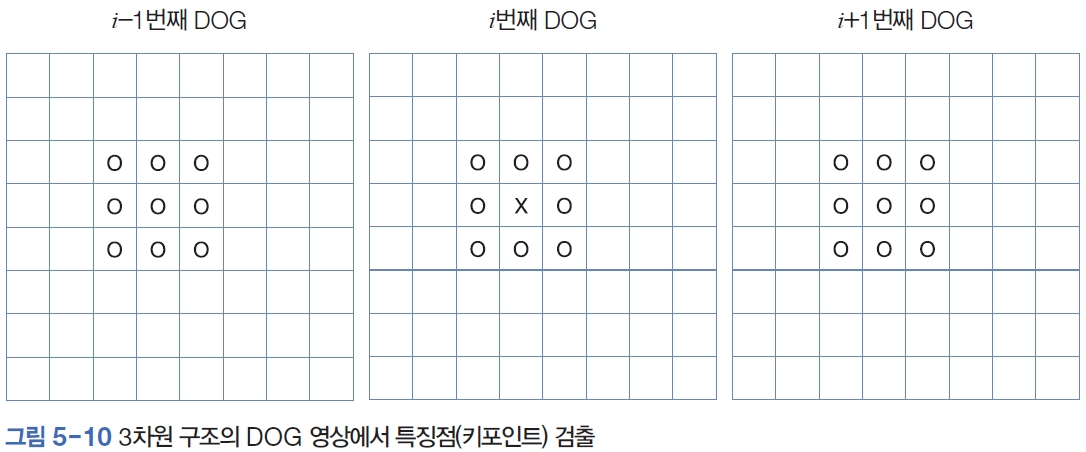

In [8]:
Image("그림 5-10.jpg", width=640)

### 2) 특이점 기술자 

- 해당 위치의 특징을 고유하게 설명하는 벡터를 생성
   - 크기 128의 벡터로 표현된: 16영역에 8개의 gradient 방향의 히스코그램  
   - 특징점 위치 $(x, y)$ 를 중심으로 각 영역의 gradient/edge의 histogram을 사용 (뇌공학적 연구와 컴퓨터 연구의 결과물) 
  
- scale, rotation, 조명등에 강인한/invariant 하도록 정의 
    - scale invariance: 앞서 검출에서 사용한 scale (o, i)를 사용   
    - 회전 invariance: 가장 강한 edge 를 기준으로 삼고 나머지 edge들로 기술함 
    - 조명 invariance: 디스크립터의 크리를 1로 normalization 함 


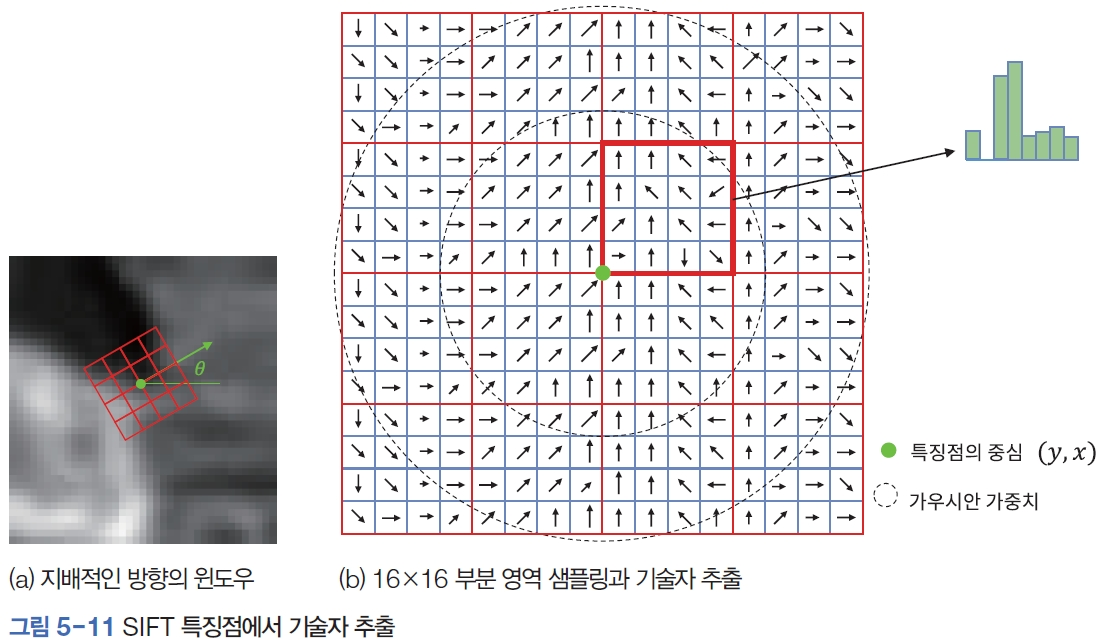

In [9]:
Image("그림 5-11.jpg", width=640)

### 그 외의 특징점들 

- SIFT 발표 이후 여러가지 특징점들이 발표 됨.
    - 특징점 검출:  SURF, FAST, AGAST 등
    - 기술자 추출:  SURF, BRIEF,  PCA-SIFT, GLOH, 모양 컨텍스트, 이진 기술자 등
    - 이외에도 Object tracking 용도로 개발된 특징점 계열도 존재
    - 이중 가장 많이 사용되는 두가지만 소개 



  


### SURF (Speeded-Up Robust Features)
- SIFT의 성능을 유지하며 속도를 대폭 개선
    - SIFT 대비 약 3~5배 빠름 (실시간성 확보 시도)
    - 미분 연산을 단순한 사각형 연산으로 대체하여 가속화
- 검출: Hessian Matrix + Integral ImageHessian 
    - Blob Detector: 이미지의 곡률(Curvature)을 분석하여 특징점 검출
    - Box Filter (근사화): SIFT의 복잡한 가우시안 미분 대신, 단순한 사각형 모양의 박스 필터를 사용하여 미분값을 근사 계산
     - Integral Image (적분 영상): 박스 필터의 합을 단 4번의 메모리 참조만으로 계산하여 스케일 공간 생성을 극도로 가속화
- 기술자: Haar-wavelet Response
    - Orientation (회전 불변): 특징점 주변 영역에서 하르 웨이블릿(Haar-wavelet) 응답을 계산하여 주방향을 결정
    - Descriptor (64차원/128차원):주변 4x4 서브 영역에서 x, y 방향의 웨이블릿 응답값의 합($\sum dx, \sum |dx|, \sum dy, \sum |dy|$)을 특징으로 사용
    - SIFT(128차원)보다 적은 64차원을 기본으로 사용하여 매칭 속도 향상

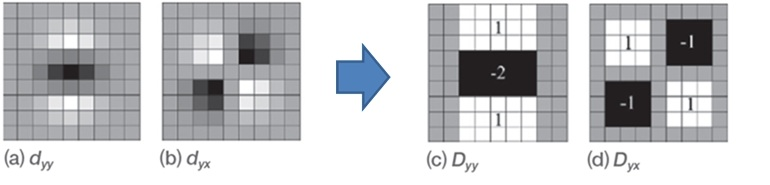

In [47]:
Image("surf_d.jpg", width=720)  # 그래디언트 계산

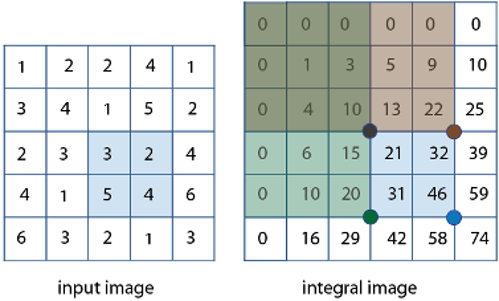

In [52]:
Image("integral_image.png", width=360)  

# 3 + 2 + 5 + 4 = 14
# 46 - 20 - 22 + 10 = 14

#### ORB   (Oriented FAST + Rotated BRIEF)  
- 완전 경량 + 실시간용으로 설계 
   - 임베디드 환경(Rassbery PI, jetson nano): 640x480 해상도는 수십, 수백 fps  
- 검출: Oriented FAST  
    - FAST (Features from Accelerated Segment Test) 
         - 검사점 근처의 거리 3만큼 떨어진 16화소를 대상
         - 이들이 연속해서 n (12)개가 현재점 보다 밝거나 어두우면 특징점
         - 조건이 안되는 경우를 우선적으로 체크하여 걸러냄으로 가속화
    - ORB는 Scale-invariance 를 위해 octave 피라미드를 만들고, 회전불변을 위해 centroid로 주방향을 잡음  
- 기술자: Rotation-aware BRIEF
    -  BRIEF를 회전 불변으로 개선 
    -  BRIEF (Binary Robust Independent Elementary Features)
         - 검사점을 기준으로 일정한 패턴쌍을 선택 
         - 이 쌍의 값의 크기를 이진화한 후 XOR를 사용 (이후에 비교시 Hamming dist 를 사용하기 위함)

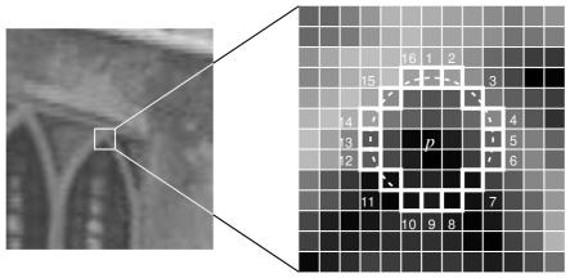

In [45]:
Image("fast.jpg", width=480)  # original FAST 

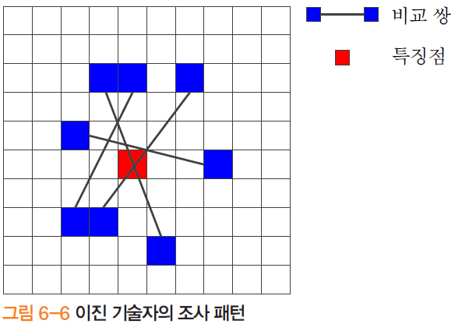

In [44]:
Image("brief.png", width=360)  # BRIEF 이진 특징기술자

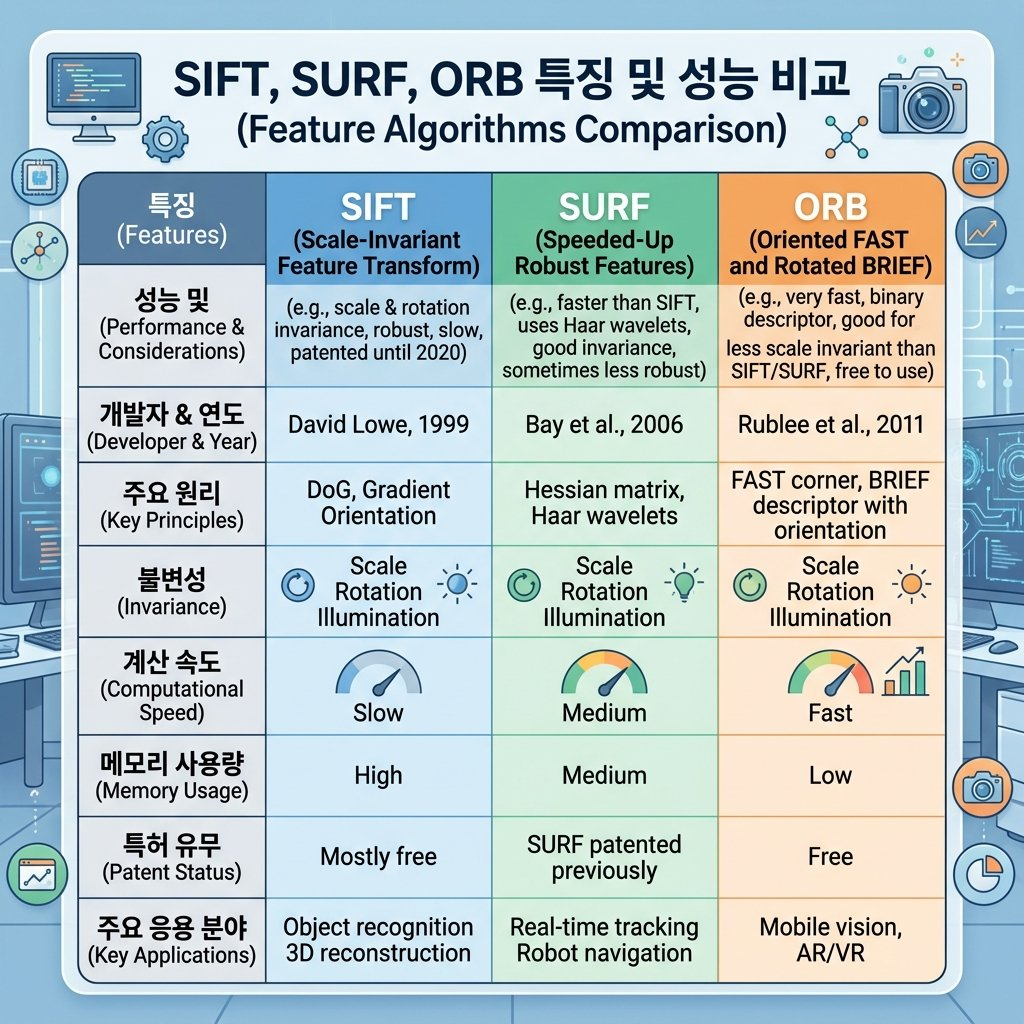

In [56]:
Image("sift_surf_orb.png", width=480)

# OpenCV  2D Feature 

- 특허 문제:  SIFT는 특허가 풀림, SURF 는 아직 몇 년 남음.

- 모두 사용방법은 유사 
    
    1. 특징점 추출 객체 생성
        - sift = cv2.xfeatures2d.SIFT_create()
        - surf = cv2.xfeatures2d.SURF_create()     
        - orb  = cv2.ORB_create()  
    2. kps = detect(gray_image, mask) 
        -  pt    : 입력 이미지에서의 (x, y) (float 값임) 
        -  response: DOG 값 
        -  octave: 하위 8bit은 octave ((-1),  0, 1, 2, 3, ...,),  상위는 layer (0, 1, 2) 
        -  size: (scale 정보) 
        
             $$size = 2 \cdot \sigma_0 \cdot 2^{octave + \frac{layer}{3}}, \sigma_0 = 1.6$$
        
        -  angle: 특징점 주위 주 graident (10도 단위)  

    3. kps, desc = compute(gray_image, kps) 
        -  desc 에는 kps에 대응되는 길이 n의 vector        

In [6]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

def detect_compute(feature2d_extractor, img_gray, N = -1, debug = False):

    start = time.time()  # 시작 시간 저장
    kps, descs = feature2d_extractor.detectAndCompute(img_gray, None)
    
    
    print("Time:", time.time() - start)  # 현재시각 - 시작시간 = 실행 시간

    print(f"num of keypoints: {len(kps)}")

    # 3. 갯수가 너무 많아서 강한것만 N 고름 
    if N == -1:
        top_N_kps = kps
        top_N_descs = descs
    else:    
        # Sort keypoints based on their response
        kps_sorted = sorted(kps, key=lambda x: x.response, reverse=True)
        top_N_kps = kps_sorted[:N]
        # Find corresponding descriptors and indices
        top_N_descs = [descs[kps.index(kp)] for kp in top_N_kps]
 
    if debug and N != -1:
        for kp, desc in zip(top_N_kps, top_N_descs):
            print("Angle:", kp.angle)        # the major orientation in angles  
            print("Class ID:", kp.class_id)  # internal parameter
            print("Octave:", kp.octave)
            print("Point:", kp.pt)           # (x, y) in original image coordinate  
            print("Response:", kp.response)  # strength of response (DOG value)
            print("Size:", kp.size)          # scale in original image 
            print("Desc:", desc)
            
    return top_N_kps, top_N_descs

In [20]:
# 거리가 너무 가까운 것을 제거 하는 함수 
def distance(f1, f2):    
    x1, y1 = f1.pt
    x2, y2 = f2.pt
    return np.sqrt((x2 - x1)**2+ (y2 - y1)**2)

def filteringByDistance(kp, distE=0.5):
    size = len(kp)
    mask = np.arange(1,size+1).astype(np.bool8) # all True   
    for i, f1 in enumerate(kp):
        if not mask[i]:
            continue
        else: # True
            for j, f2 in enumerate(kp):
                if i == j:
                    continue
                if distance(f1, f2)<distE:
                    mask[j] = False
    np_kp = np.array(kp)
    return list(np_kp[mask])

def detect_and_compute(feature2d_extractor, img_gray, N = -1, debug = False):

    '''
      검출과 기술을 두 단계로 처리 하는 예 (검출 한것 중, 중요한 것만 하기 위함)
      
    ''' 
    start = time.time()  # 시작 시간 저장
    kps = feature2d_extractor.detect(img_gray, None)
       
    kps = sorted(kps, key=lambda f: f.response, reverse=True)
    filtered_kp = list(filter(lambda f: f.response > 50, kps))
    filtered_kp = filteringByDistance(kps, 10)
    print('len(filtered_kp)=', len(filtered_kp))

    kps, descs = feature2d_extractor.compute(img_gray, filtered_kp)
    print('des.shape=', descs.shape)
    print('des=', descs)

    print("Time:", time.time() - start)  # 현재시각 - 시작시간 = 실행 시간
    print(f"num of keypoints: {len(kps)}")

    # 3. 갯수가 너무 많아서 강한것만 N 고름 
    if N == -1:
        top_N_kps = kps
        top_N_descs = descs
    else:    
        # Sort keypoints based on their response
        kps_sorted = sorted(kps, key=lambda x: x.response, reverse=True)
        top_N_kps = kps_sorted[:N]
        # Find corresponding descriptors and indices
        top_N_descs = [descs[kps.index(kp)] for kp in top_N_kps]
 
    return top_N_kps, top_N_descs

Using SIFT
Time: 0.08324122428894043
num of keypoints: 22
kps type: <class 'list'>, len: 20, first kp: (257.2728271484375, 256.1293640136719),167.80352783203125
descs type: <class 'list'>, len: 20, first desc: [  0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  30.   5.   0.   0.
   0.   0.   0.   7.  25.   2.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   2.  24.   8.   0.   0.  16.  53.
 143. 143. 143.  59.   5.   6. 143. 143. 134.  35.  15.  10.   5.  28.
  31.   4.   0.   0.   0.   0.   0.   2.   0.   0.   0.   0.  28.  18.
   0.   0.  18.  10.   8.  26. 143. 143. 114.  41. 143.  41.   7.   6.
  16.  70. 134. 143.  38.   1.   0.   0.   0.   0.   0.   7.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  23.  34.   3.
   1.   0.   0.   0.   0.   7.  43.  17.   0.   0.   0.   0.   0.   0.
   0.   0.]


(<Axes: >, <matplotlib.image.AxesImage at 0x267ae7b9880>)

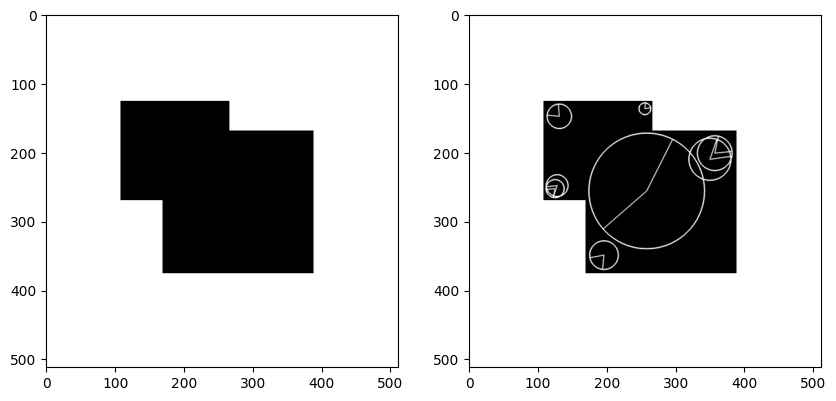

In [28]:
img_file = 'cornerTest.jpg' # 'sunflowers.jpg' # #'triangle.png'  

##src = cv2.imread('./data/')
modify = False 

img_original = cv2.imread(img_file)

method = "SIFT"  #"SIFT", "ORB","SURF" 
    
print("Using {}".format(method))
if method == "SIFT": #  SIFT (not patent is expired 
    feature2d_extractor = cv2.xfeatures2d.SIFT_create()
elif method == "SURF": #  SURF, license issue  
    feature2d_extractor = cv2.xfeatures2d.SURF_create()     
elif method == "ORB":  
    feature2d_extractor = cv2.ORB_create()  

N = 20
# original image 
img_gray = cv2.cvtColor(img_original,cv2.COLOR_BGR2GRAY) # 그레이 영상 이용  
kps, desc =  detect_compute(feature2d_extractor, img_gray, N)
#kps, desc =  detect_and_compute(feature2d_extractor, img_gray, N)
                                
print(f"kps type: {type(kps)}, len: {len(kps)}, first kp: {kps[0].pt},{kps[0].size}")
print(f"descs type: {type(desc)}, len: {len(desc)}, first desc: {desc[0]}")

img_annotated = cv2.drawKeypoints(img_gray, kps, None, color=(255,255,255), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)  
#img_annotated = cv2.drawKeypoints(cv2.cvtColor(img_gray,cv2.COLOR_GRAY2BGR), kps, None, color=(255,255,255), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)  

plt.figure(figsize = (10,12))
plt.subplot(1,2,1), plt.imshow(img_original[:,:,::-1])
plt.subplot(1,2,2), plt.imshow(img_annotated[:,:,::-1])

Time: 0.10298013687133789
num of keypoints: 12
kps type: <class 'list'>, len: 20, first kp: (257.2728271484375, 256.1293640136719),167.80352783203125
descs type: <class 'list'>, len: 20, first desc: [  0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  30.   5.   0.   0.
   0.   0.   0.   7.  25.   2.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   2.  24.   8.   0.   0.  16.  53.
 143. 143. 143.  59.   5.   6. 143. 143. 134.  35.  15.  10.   5.  28.
  31.   4.   0.   0.   0.   0.   0.   2.   0.   0.   0.   0.  28.  18.
   0.   0.  18.  10.   8.  26. 143. 143. 114.  41. 143.  41.   7.   6.
  16.  70. 134. 143.  38.   1.   0.   0.   0.   0.   0.   7.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  23.  34.   3.
   1.   0.   0.   0.   0.   7.  43.  17.   0.   0.   0.   0.   0.   0.
   0.   0.]


(<Axes: >, <matplotlib.image.AxesImage at 0x267b04887f0>)

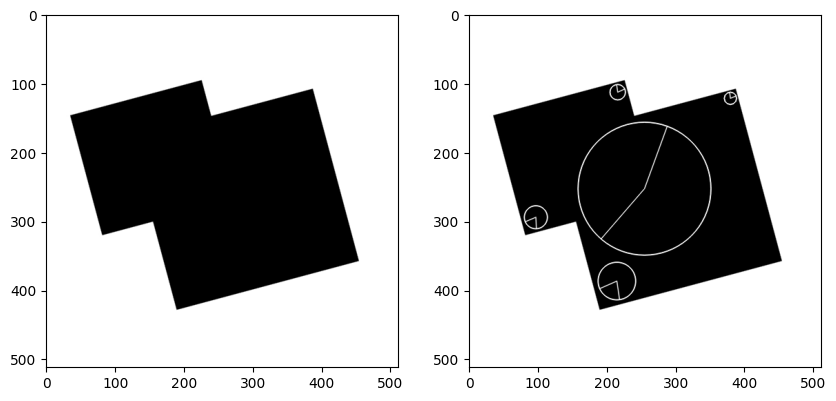

In [29]:
# Transform image (Scale and rotation)
angle = 15 #45
scale = 1.25 #0.75
# Calculate rotation matrix
height, width = img_original.shape[:2]
center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
img_modified = cv2.warpAffine(img_original, rotation_matrix, (width, height))
img_gray = cv2.cvtColor(img_modified,cv2.COLOR_BGR2GRAY) # 그레이 영상 이용  

# Feature Detection and Description 
kps_aug, desc_aug =  detect_compute(feature2d_extractor, img_gray, N)
#kps_aug, desc_aug =  detect_and_compute(feature2d_extractor, img_gray, N)
print(f"kps type: {type(kps)}, len: {len(kps)}, first kp: {kps[0].pt},{kps[0].size}")
print(f"descs type: {type(desc)}, len: {len(desc)}, first desc: {desc[0]}")

#print(kps_aug)

# Visualization 
img_annotated_aug = cv2.drawKeypoints(cv2.cvtColor(img_gray,cv2.COLOR_GRAY2BGR), kps_aug, None, (255, 255, 255), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)  # 0: default, 4: rich 

# Result 
plt.figure(figsize = (10,12))
plt.subplot(2,2,3), plt.imshow(img_modified[:,:,::-1])
plt.subplot(2,2,4), plt.imshow(img_annotated_aug[:,:,::-1])

### 끝